<a href="https://colab.research.google.com/github/dimitarpg13/agentic_architectures_and_design_patterns/blob/main/notebooks/reinforcement_learning/researcher_with_analyst_agent_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬📊 Multi-Agent Research & Analysis System with LangGraph

This notebook demonstrates a **collaborative multi-agent system** using LangGraph where a **Researcher Agent** and **Analyst Agent** work together iteratively to answer complex technical questions.

## Workflow Overview

```
┌──────────────────────────────────────────────────────────────────────────────┐
│                    MULTI-AGENT RESEARCH & ANALYSIS SYSTEM                     │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  ┌─────────┐    ┌──────────────────┐    ┌──────────────────┐                │
│  │  User   │───►│ RESEARCHER AGENT │◄──►│  ANALYST AGENT   │                │
│  │  Query  │    │                  │    │                  │                │
│  └─────────┘    │ • Search docs    │    │ • Compare options│                │
│                 │ • Find papers    │    │ • Analyze costs  │                │
│                 │ • Get benchmarks │    │ • Find challenges│                │
│                 │ • Examples       │    │ • Recommend      │                │
│                 └────────┬─────────┘    └────────┬─────────┘                │
│                          │                       │                          │
│                          ▼                       ▼                          │
│                 ┌────────────────────────────────────────────┐              │
│                 │              ITERATIVE LOOP                │              │
│                 │  Analyst requests ──► Researcher fetches   │              │
│                 │  Missing context ──► Researcher fills gaps │              │
│                 └────────────────────────────────────────────┘              │
│                                      │                                      │
│                                      ▼                                      │
│                          ┌───────────────────┐                              │
│                          │  FINAL REPORT     │                              │
│                          │  with Evidence    │                              │
│                          └───────────────────┘                              │
└──────────────────────────────────────────────────────────────────────────────┘
```

## Example Use Case
**Query:** "Should we adopt GraphRAG for our search system?"


## 1. Environment Setup


In [14]:
# Install required packages
!pip install -q langchain langchain-openai langchain-anthropic langchain-google-genai langgraph tavily-python pydantic


In [15]:
import os
import json
from typing import Annotated, List, TypedDict, Literal, Optional
from datetime import datetime
from enum import Enum

# LangChain imports
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage, ToolMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser, JsonOutputParser
from langchain_core.tools import tool
from pydantic import BaseModel, Field

# LangGraph imports
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# Web search
from tavily import TavilyClient

print("✅ All imports successful!")


✅ All imports successful!


## 2. API Configuration

Configure your LLM provider and Tavily API key for web search.


In [16]:
# Option 1: Set API keys directly (for testing - not recommended for production)
# os.environ["OPENAI_API_KEY"] = "your-openai-api-key"
# os.environ["TAVILY_API_KEY"] = "your-tavily-api-key"

# Option 2: Use getpass for secure input
from getpass import getpass

# Choose your LLM provider
LLM_PROVIDER = "openai"  # Options: "openai", "anthropic", "google"

if LLM_PROVIDER == "openai" and "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key: ")
elif LLM_PROVIDER == "anthropic" and "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = getpass("Enter your Anthropic API key: ")
elif LLM_PROVIDER == "google" and "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass("Enter your Google API key: ")

if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass("Enter your Tavily API key: ")

print(f"✅ Configured for {LLM_PROVIDER.upper()} with Tavily web search")


✅ Configured for OPENAI with Tavily web search


## 3. Initialize LLM

We'll use the same LLM for both agents but with different system prompts.


In [17]:
def get_llm(provider: str = "openai", temperature: float = 0.7):
    """Initialize the LLM based on the selected provider."""

    if provider == "openai":
        from langchain_openai import ChatOpenAI
        return ChatOpenAI(model="gpt-4o", temperature=temperature)

    elif provider == "anthropic":
        from langchain_anthropic import ChatAnthropic
        return ChatAnthropic(model="claude-sonnet-4-20250514", temperature=temperature)

    elif provider == "google":
        from langchain_google_genai import ChatGoogleGenerativeAI
        return ChatGoogleGenerativeAI(model="gemini-1.5-pro", temperature=temperature)

    else:
        raise ValueError(f"Unknown provider: {provider}")

# Initialize LLMs for different purposes
llm = get_llm(LLM_PROVIDER, temperature=0.7)
llm_structured = get_llm(LLM_PROVIDER, temperature=0.3)  # Lower temp for structured outputs

print(f"✅ LLMs initialized for {LLM_PROVIDER}")


✅ LLMs initialized for openai


## 4. Define Research Tools

The Researcher Agent has access to specialized search tools for different types of information.


In [18]:
# Initialize Tavily client
tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])


@tool
def search_technical_docs(query: str) -> str:
    """Search for technical documentation, official guides, and API references.

    Args:
        query: The technical topic to search for documentation.

    Returns:
        Technical documentation and guides related to the query.
    """
    try:
        response = tavily_client.search(
            query=f"{query} technical documentation guide tutorial",
            search_depth="advanced",
            max_results=5,
            include_answer=True,
        )

        results = []
        if response.get("answer"):
            results.append(f"📚 **Summary:** {response['answer']}\n")

        results.append("**Technical Documentation Found:**\n")
        for i, r in enumerate(response.get("results", []), 1):
            results.append(f"{i}. **{r.get('title', 'N/A')}**\n   {r.get('url', '')}\n   {r.get('content', '')[:300]}...\n")

        return "\n".join(results)
    except Exception as e:
        return f"Search error: {str(e)}"


@tool
def search_academic_papers(query: str) -> str:
    """Search for academic papers, research articles, and scientific publications.

    Args:
        query: The research topic to find academic papers about.

    Returns:
        Academic papers and research findings related to the query.
    """
    try:
        response = tavily_client.search(
            query=f"{query} research paper arxiv academic study",
            search_depth="advanced",
            max_results=5,
            include_answer=True,
        )

        results = []
        if response.get("answer"):
            results.append(f"📄 **Research Summary:** {response['answer']}\n")

        results.append("**Academic Papers & Research:**\n")
        for i, r in enumerate(response.get("results", []), 1):
            results.append(f"{i}. **{r.get('title', 'N/A')}**\n   {r.get('url', '')}\n   {r.get('content', '')[:300]}...\n")

        return "\n".join(results)
    except Exception as e:
        return f"Search error: {str(e)}"


@tool
def search_benchmarks(query: str) -> str:
    """Search for performance benchmarks, comparisons, and metrics.

    Args:
        query: The technology/method to find benchmarks for.

    Returns:
        Performance benchmarks, comparisons, and metrics.
    """
    try:
        response = tavily_client.search(
            query=f"{query} benchmark performance comparison metrics evaluation",
            search_depth="advanced",
            max_results=5,
            include_answer=True,
        )

        results = []
        if response.get("answer"):
            results.append(f"📊 **Benchmark Summary:** {response['answer']}\n")

        results.append("**Benchmarks & Performance Data:**\n")
        for i, r in enumerate(response.get("results", []), 1):
            results.append(f"{i}. **{r.get('title', 'N/A')}**\n   {r.get('url', '')}\n   {r.get('content', '')[:300]}...\n")

        return "\n".join(results)
    except Exception as e:
        return f"Search error: {str(e)}"


@tool
def search_implementation_examples(query: str) -> str:
    """Search for implementation examples, code samples, and practical guides.

    Args:
        query: The technology to find implementation examples for.

    Returns:
        Code examples, implementation guides, and practical tutorials.
    """
    try:
        response = tavily_client.search(
            query=f"{query} implementation example code github tutorial how to",
            search_depth="advanced",
            max_results=5,
            include_answer=True,
        )

        results = []
        if response.get("answer"):
            results.append(f"💻 **Implementation Summary:** {response['answer']}\n")

        results.append("**Implementation Examples:**\n")
        for i, r in enumerate(response.get("results", []), 1):
            results.append(f"{i}. **{r.get('title', 'N/A')}**\n   {r.get('url', '')}\n   {r.get('content', '')[:300]}...\n")

        return "\n".join(results)
    except Exception as e:
        return f"Search error: {str(e)}"


@tool
def search_cost_analysis(query: str) -> str:
    """Search for cost analysis, pricing, and resource requirements.

    Args:
        query: The technology to analyze costs for.

    Returns:
        Cost analysis, pricing information, and resource requirements.
    """
    try:
        response = tavily_client.search(
            query=f"{query} cost pricing analysis resources requirements infrastructure",
            search_depth="advanced",
            max_results=5,
            include_answer=True,
        )

        results = []
        if response.get("answer"):
            results.append(f"💰 **Cost Summary:** {response['answer']}\n")

        results.append("**Cost & Resource Analysis:**\n")
        for i, r in enumerate(response.get("results", []), 1):
            results.append(f"{i}. **{r.get('title', 'N/A')}**\n   {r.get('url', '')}\n   {r.get('content', '')[:300]}...\n")

        return "\n".join(results)
    except Exception as e:
        return f"Search error: {str(e)}"


# All research tools
research_tools = [
    search_technical_docs,
    search_academic_papers,
    search_benchmarks,
    search_implementation_examples,
    search_cost_analysis,
]

print("✅ Research tools defined:")
for t in research_tools:
    print(f"   🔧 {t.name}")


✅ Research tools defined:
   🔧 search_technical_docs
   🔧 search_academic_papers
   🔧 search_benchmarks
   🔧 search_implementation_examples
   🔧 search_cost_analysis


## 5. Define State Schema

The state tracks the conversation between agents, research findings, and analysis progress.


In [19]:
class AgentAction(str, Enum):
    """Actions the analyst can request."""
    NEED_MORE_RESEARCH = "need_more_research"
    READY_TO_CONCLUDE = "ready_to_conclude"


class ResearchRequest(BaseModel):
    """Structured request from Analyst to Researcher."""
    request_type: str = Field(description="Type of information needed: benchmarks, docs, papers, examples, costs")
    specific_query: str = Field(description="Specific search query to execute")
    reason: str = Field(description="Why this information is needed for the analysis")


class MultiAgentState(TypedDict):
    """State for the multi-agent research and analysis system.

    Attributes:
        messages: Full conversation history between agents
        user_query: Original user question
        research_findings: Accumulated research data
        analysis_notes: Analyst's working notes
        research_requests: Pending requests from analyst to researcher
        iteration_count: Number of research-analysis cycles
        current_agent: Which agent is currently active
        final_recommendation: The final analysis report
    """
    messages: Annotated[list, add_messages]
    user_query: str
    research_findings: List[str]
    analysis_notes: List[str]
    research_requests: List[str]
    iteration_count: int
    current_agent: str
    final_recommendation: str

print("✅ State schema defined")


✅ State schema defined


## 6. Define Agent Prompts

Each agent has a specialized system prompt defining its role and capabilities.


In [20]:
RESEARCHER_SYSTEM_PROMPT = """You are an expert Technical Researcher Agent. Your role is to gather
comprehensive information to support technical decision-making.

## Your Capabilities
You have access to specialized search tools:
- search_technical_docs: Find official documentation and guides
- search_academic_papers: Find research papers and studies
- search_benchmarks: Find performance comparisons and metrics
- search_implementation_examples: Find code examples and tutorials
- search_cost_analysis: Find pricing and resource requirements

## Your Task
Given a research request, systematically gather relevant information using your tools.
Focus on:
1. Technical documentation and official sources
2. Academic research and papers
3. Performance benchmarks and comparisons
4. Real-world implementation examples
5. Cost and resource considerations

## Guidelines
- Use multiple tools to get comprehensive coverage
- Prioritize recent and authoritative sources
- Note any conflicting information found
- Be thorough but focused on the specific request

When you have gathered sufficient information, summarize your findings clearly.
"""

ANALYST_SYSTEM_PROMPT = """You are an expert Technical Analyst Agent. Your role is to analyze
research findings and provide actionable recommendations.

## Your Task
Analyze the research provided and create a comprehensive technical assessment.

## Analysis Framework
1. **Trade-off Analysis**: Compare options on key dimensions (performance, complexity, cost)
2. **Cost/Performance Implications**: Assess resource requirements and expected benefits
3. **Integration Challenges**: Identify potential issues with existing systems
4. **Risk Assessment**: Highlight uncertainties and potential problems
5. **Recommendation**: Provide clear guidance with supporting evidence

## Decision Points
After each analysis cycle, you must decide:
- **NEED_MORE_RESEARCH**: If you need specific additional information to complete your analysis
  - Specify exactly what information you need and why
- **READY_TO_CONCLUDE**: If you have enough information to make a well-supported recommendation

## Output Format
Structure your analysis with clear sections:
- Executive Summary
- Detailed Analysis (by category)
- Key Findings
- Risks and Considerations
- Final Recommendation

Be specific, cite evidence from the research, and quantify claims when possible.
"""

COORDINATOR_PROMPT = """Based on the conversation so far, determine the next action.

If the Analyst has requested more research, extract the specific request.
If the Analyst is ready to conclude, proceed to final report generation.

Current state of the analysis:
{context}

Respond with either:
1. A specific research request if more information is needed
2. "CONCLUDE" if ready for final recommendation
"""

print("✅ Agent prompts defined")


✅ Agent prompts defined


## 7. Define Agent Nodes

Each node represents a step in the multi-agent workflow.


In [21]:
def initial_research(state: MultiAgentState) -> MultiAgentState:
    """Conduct initial comprehensive research on the user's query."""
    print("\n" + "="*60)
    print("🔬 RESEARCHER AGENT: Initial Research Phase")
    print("="*60)

    query = state["user_query"]

    # Create research prompt
    research_prompt = f"""Please conduct comprehensive research on the following question:

"{query}"

Use your available tools to gather:
1. Technical documentation and official information
2. Academic research and papers
3. Performance benchmarks and comparisons
4. Implementation examples
5. Cost considerations

Be thorough and systematic in your research."""

    # Bind tools to the LLM
    llm_with_tools = llm.bind_tools(research_tools)

    messages = [
        SystemMessage(content=RESEARCHER_SYSTEM_PROMPT),
        HumanMessage(content=research_prompt)
    ]

    # Let the researcher work with tools
    all_findings = []
    for i in range(5):  # Max 5 tool calls in initial research
        response = llm_with_tools.invoke(messages)
        messages.append(response)

        if not response.tool_calls:
            break

        # Execute tool calls
        for tool_call in response.tool_calls:
            tool_name = tool_call["name"]
            tool_args = tool_call["args"]
            tool_call_id = tool_call["id"]
            print(f"   🔧 Using tool: {tool_name}")

            # Find and execute the tool
            tool_fn = next((t for t in research_tools if t.name == tool_name), None)
            if tool_fn:
                result = tool_fn.invoke(tool_args)
                all_findings.append(f"[{tool_name}]: {result}")
                # Use ToolMessage with tool_call_id for proper API formatting
                messages.append(ToolMessage(content=result, tool_call_id=tool_call_id))

    # Get final summary from researcher
    summary_prompt = "Please summarize all the research findings you've gathered in a structured format."
    messages.append(HumanMessage(content=summary_prompt))
    summary = llm.invoke(messages)

    print(f"\n📋 Research Summary Generated")

    return {
        **state,
        "messages": [
            SystemMessage(content=RESEARCHER_SYSTEM_PROMPT),
            HumanMessage(content=f"Research Request: {query}"),
            AIMessage(content=summary.content)
        ],
        "research_findings": all_findings + [summary.content],
        "current_agent": "analyst",
        "iteration_count": 1,
    }


def analyze_research(state: MultiAgentState) -> MultiAgentState:
    """Analyst reviews research and either requests more or concludes."""
    print("\n" + "="*60)
    print("📊 ANALYST AGENT: Analysis Phase")
    print("="*60)

    # Compile all research for the analyst
    findings_text = "\n\n---\n\n".join(state["research_findings"])

    analysis_prompt = f"""Please analyze the following research findings for the question:

**Original Question:** {state["user_query"]}

**Research Findings:**
{findings_text}

**Instructions:**
1. Analyze the trade-offs and implications
2. Identify any gaps in the research
3. Either:
   - Request specific additional research by saying "NEED_MORE_RESEARCH:" followed by what you need
   - Or provide your complete analysis and recommendation if you have enough information

Consider:
- GraphRAG vs traditional RAG trade-offs
- Cost and performance implications
- Integration challenges
- Clear recommendation with evidence"""

    messages = [
        SystemMessage(content=ANALYST_SYSTEM_PROMPT),
        HumanMessage(content=analysis_prompt)
    ]

    response = llm.invoke(messages)
    analysis = response.content

    print(f"\n📝 Analysis complete")

    # Check if analyst needs more research
    needs_more = "NEED_MORE_RESEARCH" in analysis.upper()

    return {
        **state,
        "messages": state["messages"] + [
            HumanMessage(content="Please analyze the research and provide your assessment."),
            AIMessage(content=analysis)
        ],
        "analysis_notes": state["analysis_notes"] + [analysis],
        "current_agent": "researcher" if needs_more else "final",
        "research_requests": [analysis] if needs_more else [],
    }


def additional_research(state: MultiAgentState) -> MultiAgentState:
    """Researcher conducts additional research based on analyst's request."""
    print("\n" + "="*60)
    print("🔬 RESEARCHER AGENT: Additional Research Phase")
    print("="*60)

    # Extract what the analyst needs
    last_analysis = state["analysis_notes"][-1] if state["analysis_notes"] else ""

    research_prompt = f"""The analyst has requested additional research.

Their analysis so far:
{last_analysis}

Please search for the specific information they need to complete their analysis.
Focus on filling the gaps they've identified."""

    llm_with_tools = llm.bind_tools(research_tools)

    messages = [
        SystemMessage(content=RESEARCHER_SYSTEM_PROMPT),
        HumanMessage(content=research_prompt)
    ]

    new_findings = []
    for i in range(3):  # Max 3 additional tool calls
        response = llm_with_tools.invoke(messages)
        messages.append(response)

        if not response.tool_calls:
            break

        for tool_call in response.tool_calls:
            tool_name = tool_call["name"]
            tool_args = tool_call["args"]
            tool_call_id = tool_call["id"]
            print(f"   🔧 Additional search: {tool_name}")

            tool_fn = next((t for t in research_tools if t.name == tool_name), None)
            if tool_fn:
                result = tool_fn.invoke(tool_args)
                new_findings.append(f"[Additional - {tool_name}]: {result}")
                # Use ToolMessage with tool_call_id for proper API formatting
                messages.append(ToolMessage(content=result, tool_call_id=tool_call_id))

    # Summarize new findings
    messages.append(HumanMessage(content="Summarize the additional findings."))
    summary = llm.invoke(messages)
    new_findings.append(summary.content)

    print(f"\n📋 Additional research complete")

    return {
        **state,
        "messages": state["messages"] + [AIMessage(content=summary.content)],
        "research_findings": state["research_findings"] + new_findings,
        "current_agent": "analyst",
        "iteration_count": state["iteration_count"] + 1,
    }


def generate_final_report(state: MultiAgentState) -> MultiAgentState:
    """Generate the final comprehensive recommendation report."""
    print("\n" + "="*60)
    print("📄 GENERATING FINAL REPORT")
    print("="*60)

    all_research = "\n\n".join(state["research_findings"])
    all_analysis = "\n\n".join(state["analysis_notes"])

    final_prompt = f"""Based on all the research and analysis conducted, create a comprehensive
final recommendation report for the question:

**Question:** {state["user_query"]}

**All Research Findings:**
{all_research}

**Analysis Notes:**
{all_analysis}

Create a professional report with:
1. **Executive Summary** - Key takeaway in 2-3 sentences
2. **Technology Comparison** - GraphRAG vs Traditional RAG
3. **Performance Analysis** - Benchmarks and metrics
4. **Cost Analysis** - Resource and infrastructure requirements
5. **Integration Considerations** - Challenges with existing systems
6. **Risk Assessment** - Potential issues and mitigations
7. **Final Recommendation** - Clear guidance with confidence level
8. **Next Steps** - Actionable items if adopting

Be specific, cite evidence, and provide actionable guidance."""

    messages = [
        SystemMessage(content="You are an expert technical writer creating a final recommendation report."),
        HumanMessage(content=final_prompt)
    ]

    response = llm.invoke(messages)

    return {
        **state,
        "final_recommendation": response.content,
        "current_agent": "complete",
    }


print("✅ Agent nodes defined")


✅ Agent nodes defined


## 8. Define Routing Logic

The router directs flow between agents based on the analysis state.


In [22]:
def route_after_analysis(state: MultiAgentState) -> Literal["additional_research", "final_report"]:
    """Route based on whether analyst needs more research."""

    # Check iteration limit
    if state["iteration_count"] >= 3:
        print("⏹️ Max iterations reached, proceeding to final report")
        return "final_report"

    # Check what the analyst decided
    if state["current_agent"] == "researcher":
        print("🔄 Analyst requested additional research")
        return "additional_research"
    else:
        print("✅ Analyst ready to conclude")
        return "final_report"


def route_after_additional_research(state: MultiAgentState) -> Literal["analyze"]:
    """After additional research, always go back to analyst."""
    return "analyze"


print("✅ Routing logic defined")


✅ Routing logic defined


## 9. Build the Multi-Agent Graph

Assemble the complete workflow with LangGraph.


In [23]:
def build_multi_agent_system():
    """Build the Researcher + Analyst multi-agent graph."""

    workflow = StateGraph(MultiAgentState)

    # Add nodes
    workflow.add_node("initial_research", initial_research)
    workflow.add_node("analyze", analyze_research)
    workflow.add_node("additional_research", additional_research)
    workflow.add_node("final_report", generate_final_report)

    # Define edges
    workflow.add_edge(START, "initial_research")
    workflow.add_edge("initial_research", "analyze")

    # Conditional routing after analysis
    workflow.add_conditional_edges(
        "analyze",
        route_after_analysis,
        {
            "additional_research": "additional_research",
            "final_report": "final_report",
        }
    )

    # After additional research, go back to analyst
    workflow.add_edge("additional_research", "analyze")

    # Final report ends the workflow
    workflow.add_edge("final_report", END)

    return workflow.compile()


# Build the system
multi_agent_system = build_multi_agent_system()

print("✅ Multi-Agent System built successfully!")
print("\nWorkflow:")
print("START → Initial Research → Analyze ⟷ Additional Research → Final Report → END")


✅ Multi-Agent System built successfully!

Workflow:
START → Initial Research → Analyze ⟷ Additional Research → Final Report → END


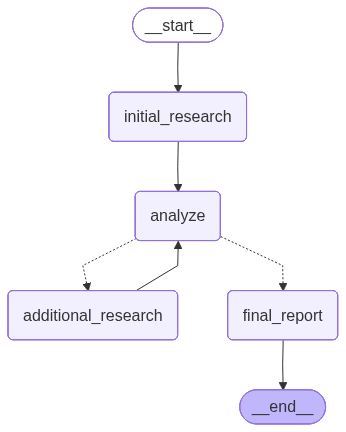

In [24]:
# Visualize the graph (optional)
try:
    from IPython.display import Image, display
    display(Image(multi_agent_system.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph visualization not available.")
    print("\nWorkflow structure:")
    print("""
    ┌─────────────────┐
    │      START      │
    └────────┬────────┘
             │
             ▼
    ┌─────────────────┐
    │ Initial Research│
    └────────┬────────┘
             │
             ▼
    ┌─────────────────┐     ┌─────────────────┐
    │    Analyze      │────►│ Additional      │
    │   (Analyst)     │◄────│ Research        │
    └────────┬────────┘     └─────────────────┘
             │
             ▼
    ┌─────────────────┐
    │  Final Report   │
    └────────┬────────┘
             │
             ▼
    ┌─────────────────┐
    │      END        │
    └─────────────────┘
    """)


## 10. Run the Multi-Agent System

Let's test with the GraphRAG example query!


In [25]:
def run_analysis(query: str) -> str:
    """Run the multi-agent research and analysis system.

    Args:
        query: The technical question to research and analyze.

    Returns:
        The final recommendation report.
    """
    print("="*70)
    print("🤖 MULTI-AGENT RESEARCH & ANALYSIS SYSTEM")
    print("="*70)
    print(f"\n📌 Query: {query}\n")
    print("="*70)

    # Initialize state
    initial_state = {
        "messages": [],
        "user_query": query,
        "research_findings": [],
        "analysis_notes": [],
        "research_requests": [],
        "iteration_count": 0,
        "current_agent": "researcher",
        "final_recommendation": "",
    }

    # Run the system
    final_state = multi_agent_system.invoke(initial_state)

    # Display final report
    print("\n" + "="*70)
    print("📊 FINAL RECOMMENDATION REPORT")
    print("="*70)
    print(final_state["final_recommendation"])
    print("\n" + "="*70)
    print(f"📈 Total research iterations: {final_state['iteration_count']}")
    print("="*70)

    return final_state["final_recommendation"]


In [26]:
# Primary Example: GraphRAG Adoption Decision
graphrag_query = """Should we adopt GraphRAG for our search system?

Context:
- We currently have a traditional RAG system using vector embeddings
- Our documents contain complex relationships between entities
- We need to handle multi-hop reasoning queries
- Budget and infrastructure constraints are a consideration

Please provide a comprehensive analysis and recommendation."""

report = run_analysis(graphrag_query)


🤖 MULTI-AGENT RESEARCH & ANALYSIS SYSTEM

📌 Query: Should we adopt GraphRAG for our search system?

Context:
- We currently have a traditional RAG system using vector embeddings
- Our documents contain complex relationships between entities
- We need to handle multi-hop reasoning queries
- Budget and infrastructure constraints are a consideration

Please provide a comprehensive analysis and recommendation.


🔬 RESEARCHER AGENT: Initial Research Phase
   🔧 Using tool: search_technical_docs
   🔧 Using tool: search_academic_papers
   🔧 Using tool: search_benchmarks
   🔧 Using tool: search_implementation_examples
   🔧 Using tool: search_cost_analysis

📋 Research Summary Generated

📊 ANALYST AGENT: Analysis Phase

📝 Analysis complete
✅ Analyst ready to conclude

📄 GENERATING FINAL REPORT

📊 FINAL RECOMMENDATION REPORT
# Final Recommendation Report: Adoption of GraphRAG for Enhanced Search System

## Executive Summary
This report evaluates the potential adoption of GraphRAG to enhance our cu

## 11. Additional Example Queries

Try other technical decision queries:


In [30]:
# Example 2: LLM Framework Selection
framework_query = """Should we use LangChain or LlamaIndex for our enterprise RAG application?

Context:
- Building a document Q&A system for internal knowledge base
- Need to support multiple document types (PDF, Word, HTML)
- Require integration with Azure OpenAI
- Team has Python experience but new to LLM frameworks

Please compare and recommend."""

# Uncomment to run:
report = run_analysis(framework_query)


🤖 MULTI-AGENT RESEARCH & ANALYSIS SYSTEM

📌 Query: Should we use LangChain or LlamaIndex for our enterprise RAG application?

Context:
- Building a document Q&A system for internal knowledge base
- Need to support multiple document types (PDF, Word, HTML)
- Require integration with Azure OpenAI
- Team has Python experience but new to LLM frameworks

Please compare and recommend.


🔬 RESEARCHER AGENT: Initial Research Phase
   🔧 Using tool: search_technical_docs
   🔧 Using tool: search_technical_docs
   🔧 Using tool: search_academic_papers
   🔧 Using tool: search_benchmarks
   🔧 Using tool: search_implementation_examples
   🔧 Using tool: search_implementation_examples
   🔧 Using tool: search_cost_analysis
   🔧 Using tool: search_cost_analysis

📋 Research Summary Generated

📊 ANALYST AGENT: Analysis Phase

📝 Analysis complete
✅ Analyst ready to conclude

📄 GENERATING FINAL REPORT

📊 FINAL RECOMMENDATION REPORT
# Final Recommendation Report: LangChain vs. LlamaIndex for Enterprise RAG App

In [31]:
# Example 3: Vector Database Selection
vectordb_query = """Which vector database should we choose: Pinecone, Weaviate, or Milvus?

Context:
- Expected to store 10 million+ embeddings
- Need low-latency queries (<100ms p99)
- Want to minimize operational overhead
- Budget is flexible but cost-efficiency matters
- Running on AWS infrastructure

Please analyze and recommend."""

# Uncomment to run:
report = run_analysis(vectordb_query)


🤖 MULTI-AGENT RESEARCH & ANALYSIS SYSTEM

📌 Query: Which vector database should we choose: Pinecone, Weaviate, or Milvus?

Context:
- Expected to store 10 million+ embeddings
- Need low-latency queries (<100ms p99)
- Want to minimize operational overhead
- Budget is flexible but cost-efficiency matters
- Running on AWS infrastructure

Please analyze and recommend.


🔬 RESEARCHER AGENT: Initial Research Phase
   🔧 Using tool: search_technical_docs
   🔧 Using tool: search_technical_docs
   🔧 Using tool: search_technical_docs
   🔧 Using tool: search_academic_papers
   🔧 Using tool: search_benchmarks
   🔧 Using tool: search_implementation_examples
   🔧 Using tool: search_implementation_examples
   🔧 Using tool: search_implementation_examples
   🔧 Using tool: search_cost_analysis

📋 Research Summary Generated

📊 ANALYST AGENT: Analysis Phase

📝 Analysis complete
✅ Analyst ready to conclude

📄 GENERATING FINAL REPORT

📊 FINAL RECOMMENDATION REPORT
# Final Recommendation Report: Choosing a Ve

In [ ]:
# Try your own technical decision query!
custom_query = """
Your question here...

Context:
- Add relevant context
- Include constraints
- Mention current setup
"""

# Uncomment to run:
# report = run_analysis(custom_query)


## 12. Summary

This notebook demonstrates a **Multi-Agent Research & Analysis System** with two specialized agents working together iteratively.

### Agent Roles

| Agent | Role | Capabilities |
|-------|------|--------------|
| 🔬 **Researcher** | Information Gathering | Search docs, papers, benchmarks, examples, costs |
| 📊 **Analyst** | Critical Analysis | Compare trade-offs, assess costs, identify challenges, recommend |

### Workflow Features

1. **Initial Research Phase**
   - Researcher conducts comprehensive information gathering
   - Uses 5 specialized search tools
   - Produces structured findings

2. **Analysis Phase**
   - Analyst reviews all research
   - Identifies gaps and requests additional research if needed
   - Produces trade-off analysis

3. **Iterative Refinement**
   - Analyst can request specific additional research
   - Researcher fills gaps with targeted searches
   - Loop continues until analyst is satisfied (max 3 iterations)

4. **Final Report**
   - Comprehensive recommendation with evidence
   - Structured sections covering all decision factors
   - Clear actionable guidance

### Key Benefits

- ✅ **Separation of concerns**: Research and analysis are distinct skills
- ✅ **Iterative refinement**: Gaps are identified and filled
- ✅ **Structured output**: Professional reports with evidence
- ✅ **Flexible**: Works for various technical decision queries
- ✅ **Traceable**: Full history of research and analysis steps


In [ ]:
print("\n🎉 Multi-Agent Research & Analysis System Complete!")
print("\nThis system demonstrates:")
print("  • Researcher Agent: Systematic information gathering with specialized tools")
print("  • Analyst Agent: Critical analysis and recommendation generation")
print("  • Iterative Loop: Analyst can request additional research as needed")
print("  • Final Report: Comprehensive recommendation with supporting evidence")
print("\nModify the prompts or add new tools to customize for your use case!")
